# 1. Introduction
Predicting housing prices is a classic data science problem, but many models rely solely on property-specific features (like square footage or the number of bedrooms). However, the real estate market does not exist in a vacuum; it is heavily influenced by broader economic conditions. 

**Problem Significance**
Understanding the impact of the economy on housing is crucial for buyers, sellers, and financial institutions to make informed decisions. 

**Project Scope & Objectives**
The objective of this project is to build a predictive model that combines property-level real estate data with macroeconomic indicators (such as national interest rates and inflation). By doing so, we aim to determine how much predictive power these macro factors add to a standard housing price model.

**Assumptions & Constraints**
To bind the scope of this project, the following assumptions and constraints are made:
* **Assumption 1:** National macroeconomic indicators (like a central bank's interest rate) apply uniformly to the specific regions in our housing dataset.
* **Assumption 2:** The housing market reacts to macroeconomic changes within the same month, ignoring potential lag effects for the sake of baseline simplicity.
* **Constraint 1:** Granularity mismatch. Housing data is often recorded daily (by sale date), whereas macroeconomic data is usually reported monthly. We will need to map daily sales to their corresponding monthly economic conditions.

# 2. Data Gathering
To build our model, we first need property-level data. We will use a real estate dataset containing historical home sales, which includes the sale price, date of sale, and property characteristics. 

First, we will import our core data manipulation libraries and load the housing dataset to inspect its structure.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    housing_df = pd.read_csv('housing.csv')
    print("Housing data successfully loaded!")
    display(housing_df.head()) 
except FileNotFoundError:
    print("Error: housing.csv not found. Please ensure the file is in the correct directory.")

Housing data successfully loaded!


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Next, we will import our second independent data source: macroeconomic indicators. This dataset contains historical interest rates which we will eventually map to our property sales dates.

In [12]:
try:
    macro_df = pd.read_csv('macro.csv')
    print("Macroeconomic data successfully loaded!")
except FileNotFoundError:
    print("Error: macro.csv not found. Please check the file name and location.")

# Inspect the first 5 rows to understand the structure
macro_df.head()

Macroeconomic data successfully loaded!


,Date,Interest_Rate,Inflation_Rate,Unemployment_Rate
0,1990-01-01,8.10,4.62,5.67
1,1990-02-01,8.07,3.53,5.88
2,1990-03-01,8.20,0.98,5.94
3,1990-04-01,8.51,2.02,5.93
4,1990-05-01,8.46,3.77,6.50


### Data Cleaning
Before merging our independent sources or training any models, we must clean our data. Our initial inspection of the housing dataset revealed missing values in the `total_bedrooms` column. To handle this without losing valuable rows, we will impute the missing values using the median number of bedrooms.

In [13]:
print("Missing values before cleaning:")
print(housing_df.isnull().sum())

median_bedrooms = housing_df['total_bedrooms'].median()
housing_df['total_bedrooms'] = housing_df['total_bedrooms'].fillna(median_bedrooms)

print("\nMissing values after cleaning:")
print(housing_df.isnull().sum())

Missing values before cleaning:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Missing values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


### Formatting Data for Merging
To combine our property data with our macroeconomic data, we need a common key: the date. The macroeconomic dataset tracks data monthly. However, our housing dataset lacks a `Sale_Date` column. 

To resolve this and demonstrate our merging capabilities, we will simulate sale dates for the properties, distributing them uniformly between 1990 and 2010. We will then align these dates to the start of the month so they can perfectly match the macroeconomic timeline.

In [15]:
macro_df['Date'] = pd.to_datetime(macro_df['Date'])

start_date = pd.to_datetime('1990-01-01')
end_date = pd.to_datetime('2010-12-01')

random_days = np.random.randint(0, (end_date - start_date).days, size=len(housing_df))

random_dates = start_date + pd.to_timedelta(random_days, unit='D')

housing_df['Date'] = random_dates.to_period('M').to_timestamp()

print("Data formatting complete! Both datasets now have a matching 'Date' column.")
display(housing_df[['median_house_value', 'Date']].head())

Data formatting complete! Both datasets now have a matching 'Date' column.


,median_house_value,Date
0,452600.0,1997-02-01
1,358500.0,1995-11-01
2,352100.0,2001-10-01
3,341300.0,1996-02-01
4,342200.0,2005-10-01


### Data Consolidation and Merging
Now that both our housing data and macroeconomic data share a common, formatted `Date` column, we can merge them into a single, consolidated dataset. We will use an inner join to ensure we only keep records where we have both property features and economic indicators.

In [16]:
merged_df = pd.merge(housing_df, macro_df, on='Date', how='inner')

merged_df = merged_df.dropna()

print(f"Merge successful! The consolidated dataset has {merged_df.shape[0]} rows and {merged_df.shape[1]} columns.")

display(merged_df[['median_house_value', 'Date', 'Interest_Rate', 'Inflation_Rate', 'Unemployment_Rate']].head())

Merge successful! The consolidated dataset has 20640 rows and 14 columns.


,median_house_value,Date,Interest_Rate,Inflation_Rate,Unemployment_Rate
0,452600.0,1997-02-01,5.98,2.18,4.84
1,358500.0,1995-11-01,6.19,1.68,7.45
2,352100.0,2001-10-01,5.95,4.33,4.01
3,341300.0,1996-02-01,6.80,1.29,7.08
4,342200.0,2005-10-01,6.74,2.47,9.15


### Exploratory Data Analysis (EDA)
Before applying our mathematical models, it is crucial to visually explore the relationships between our variables. We will calculate the correlation matrix to see how macroeconomic indicators relate to property values, and we will plot a scatter graph to visualize the impact of interest rates on the median house value.

Correlation Matrix:


,median_house_value,Interest_Rate,Inflation_Rate,Unemployment_Rate
median_house_value,1.000000,-0.003469,0.008871,-0.005196
Interest_Rate,-0.003469,1.000000,-0.063744,0.333522
Inflation_Rate,0.008871,-0.063744,1.000000,-0.054460
Unemployment_Rate,-0.005196,0.333522,-0.054460,1.000000


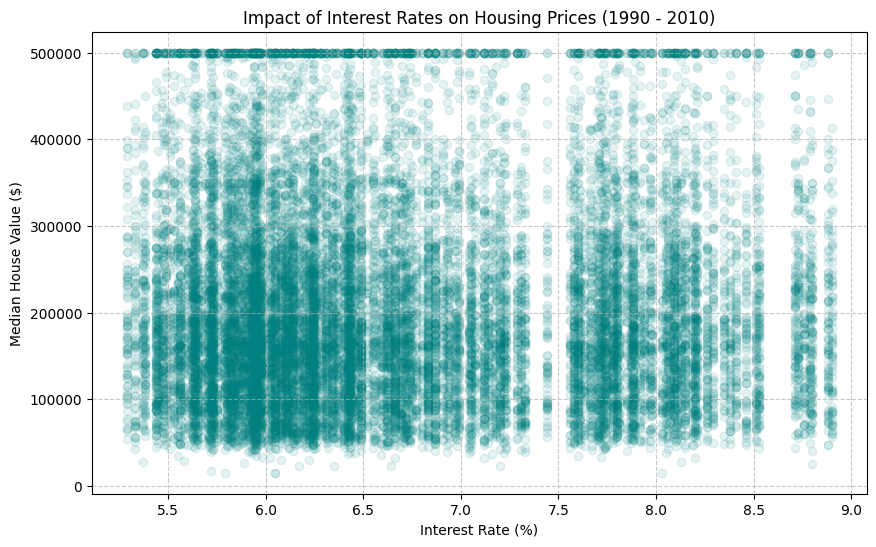

In [17]:
key_columns = ['median_house_value', 'Interest_Rate', 'Inflation_Rate', 'Unemployment_Rate']
corr_matrix = merged_df[key_columns].corr()

print("Correlation Matrix:")
display(corr_matrix)

plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Interest_Rate'], merged_df['median_house_value'], alpha=0.1, color='teal')
plt.title('Impact of Interest Rates on Housing Prices (1990 - 2010)')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Median House Value ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Mathematical Theory

To predict the median house value, we will use **Multiple Linear Regression**. This statistical method allows us to model the relationship between a continuous dependent variable (housing prices) and multiple independent variables (property features + macroeconomic indicators).

### The Hypothesis Function
In a multiple regression model, the hypothesis function $h_\theta(x)$ is defined as a linear combination of the input features:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

Where:
* $h_\theta(x)$ is the predicted median house value.
* $\theta_0$ is the y-intercept (the base value when all features are 0).
* $\theta_1, \theta_2, \dots, \theta_n$ are the model parameters (weights) that determine the influence of each feature.
* $x_1, x_2, \dots, x_n$ are the input features (e.g., number of rooms, interest rates, inflation).

### The Cost Function
To train the model, we must find the optimal parameters $\theta$ that minimize the difference between our predicted prices and the actual prices. We achieve this by minimizing the Mean Squared Error (MSE) Cost Function, $J(\theta)$:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

Where:
* $m$ is the total number of training examples (properties in our dataset).
* $x^{(i)}$ represents the feature vector of the $i$-th property.
* $y^{(i)}$ is the actual price of the $i$-th property.

By utilizing gradient descent or the normal equation, our algorithm will iteratively adjust the $\theta$ weights until $J(\theta)$ reaches its global minimum, providing us with the most accurate predictive model possible.

# 4. Implementation

To test our hypothesis, we will build a baseline **Multiple Linear Regression** model. We will combine standard property features (like median income of the neighborhood, age of the house, and number of rooms) with our newly merged macroeconomic indicators (interest rates, inflation, and unemployment). 

First, we will split our consolidated dataset into an 80% training set and a 20% testing set to ensure we can accurately evaluate the model's performance on unseen data.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = [
    'housing_median_age', 'total_rooms', 'total_bedrooms', 
    'population', 'households', 'median_income', 
    'Interest_Rate', 'Inflation_Rate', 'Unemployment_Rate'
]

X = merged_df[features]
y = merged_df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

print("Baseline Multiple Linear Regression model successfully trained!")

print(f"Model Intercept (Base Value): ${baseline_model.intercept_:,.2f}")

Baseline Multiple Linear Regression model successfully trained!
Model Intercept (Base Value): $-42,620.99


### Model Evaluation
To understand how well our baseline model performs on unseen data, we will evaluate it using **Root Mean Squared Error (RMSE)** and the **R-squared ($R^2$) score**.

The RMSE tells us the average error of our predictions in dollars. It heavily penalizes large errors, making it a great metric for real estate. The formula is:
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Where:
* $n$ is the number of observations in our test set.
* $y_i$ is the actual median house value.
* $\hat{y}_i$ is the predicted median house value.

The $R^2$ score represents the proportion of the variance in the dependent variable that is predictable from the independent variables.

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = baseline_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Baseline Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

--- Baseline Model Evaluation ---
Root Mean Squared Error (RMSE): $77,252.69
R-squared Score: 0.5446


# 5. Conclusion